In [52]:
print("lets start!")

lets start!


In [88]:
import pandas as pd 
import re 
import tqdm
import matplotlib.pyplot as plt 
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_selection import chi2
import numpy as np 

In [54]:
json_df= pd.read_json(r"C:\Users\rk186\OneDrive\Desktop\ocr-image-text-analysis\ocr_converted.jsonl",lines=True)
json_df.head()

,_id,error,qtype,ocr_fields,has_dead_images,NCERTref,ncert_source
0,{'$oid': '61024798bd61f315655274e0'},1,scq,"{'solution': {'field_path': 'scq.solution', 'o...",False,NaN,NaN
1,{'$oid': '63e78ccd8a90e86dacae5dbd'},1,scq,"{'question': {'field_path': 'scq.question', 'o...",False,NaN,NaN
2,{'$oid': '5f509f8fbd434d3145203a25'},1,scq,"{'solution': {'field_path': 'scq.solution', 'o...",False,NaN,NaN
3,{'$oid': '63e78ccd888a746db2a71464'},1,scq,"{'solution': {'field_path': 'scq.solution', 'o...",False,NaN,NaN
4,{'$oid': '5f509f8fbd434d3145203a26'},1,scq,"{'solution': {'field_path': 'scq.solution', 'o...",False,NaN,NaN


In [55]:
json_df.ocr_fields[0]

{'solution': {'field_path': 'scq.solution',
  'ocr_text': '\\( A \\cap \\phi = \\phi \\)',
  'ocr_latex': 'A \\cap \\phi = \\phi',
  'avg_confidence': 0.0,
  'image_count': 1,
  'image_urls': ['https://acadza-check-new.s3.ap-south-1.amazonaws.com/fn_U86r17X'],
  'html': '<math xmlns="http://www.w3.org/1998/Math/MathML" display="inline"><mstyle displaystyle="true"><mrow><mi>A</mi><mo>&#x02229;</mo><mi>&#x003D5;</mi><mo>&#x0003D;</mo><mi>&#x003D5;</mi></mrow></mstyle></math>',
  'latex_conversion_success': 1,
  'latex_conversion_fail': 0}}

In [56]:
json_df.ocr_fields[2]

{'solution': {'field_path': 'scq.solution',
  'ocr_text': '\\( \\sin ^ { 2 } \\theta = \\frac { 1 } { 4 } = \\) \\( \\sin ^ { 2 } \\frac { \\pi } { 6 } \\Rightarrow \\theta = n \\pi \\pm \\frac { \\pi } { 6 } \\)',
  'ocr_latex': '\\sin ^ { 2 } \\theta = \\frac { 1 } { 4 } = \\sin ^ { 2 } \\frac { \\pi } { 6 } \\Rightarrow \\theta = n \\pi \\pm \\frac { \\pi } { 6 }',
  'avg_confidence': 0.0,
  'image_count': 2,
  'image_urls': ['https://acadza-check.s3.amazonaws.com/91vnwyK8j',
   'https://acadza-check.s3.amazonaws.com/8MFsuD3An'],
  'html': '<math xmlns="http://www.w3.org/1998/Math/MathML" display="inline"><mstyle displaystyle="true"><mrow><msup><mi>sin</mi><mrow><mn>2</mn></mrow></msup><mi>&#x003B8;</mi><mo>&#x0003D;</mo><mfrac><mrow><mn>1</mn></mrow><mrow><mn>4</mn></mrow></mfrac><mo>&#x0003D;</mo></mrow></mstyle></math> <math xmlns="http://www.w3.org/1998/Math/MathML" display="inline"><mstyle displaystyle="true"><mrow><msup><mi>sin</mi><mrow><mn>2</mn></mrow></msup><mfrac><mrow><m

In [57]:
json_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19633 entries, 0 to 19632
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   _id              19633 non-null  object
 1   error            19633 non-null  int64 
 2   qtype            19633 non-null  str   
 3   ocr_fields       19633 non-null  object
 4   has_dead_images  19633 non-null  bool  
 5   NCERTref         9 non-null      str   
 6   ncert_source     9 non-null      str   
dtypes: bool(1), int64(1), object(2), str(3)
memory usage: 939.6+ KB


In [58]:
print("Null values:\n", json_df.isnull().sum())
print("Number of duplicate rows:", json_df.astype("str").duplicated().sum())

Null values:
 _id                    0
error                  0
qtype                  0
ocr_fields             0
has_dead_images        0
NCERTref           19624
ncert_source       19624
dtype: int64
Number of duplicate rows: 0


In [59]:
json_df.shape

(19633, 7)

In [60]:
json_df.columns

Index(['_id', 'error', 'qtype', 'ocr_fields', 'has_dead_images', 'NCERTref',
       'ncert_source'],
      dtype='str')

In [61]:
json_df.ocr_fields[1]

{'question': {'field_path': 'scq.question',
  'ocr_text': '\\( F = 6 t \\) acts on a particle of mass 1 kg',
  'ocr_latex': 'F = 6 t \\text { acts on a particle of mass } 1 \\mathrm {~kg}',
  'avg_confidence': 0.0,
  'image_count': 1,
  'image_urls': ['https://acadza-check-new.s3.ap-south-1.amazonaws.com/GTfeMuauSimage.png'],
  'html': '<math xmlns="http://www.w3.org/1998/Math/MathML" display="inline"><mstyle displaystyle="true"><mrow><mi>F</mi><mo>&#x0003D;</mo><mn>6</mn><mi>t</mi></mrow></mstyle></math> acts on a particle of mass 1 kg',
  'latex_conversion_success': 1,
  'latex_conversion_fail': 0},
 'solution': {'field_path': 'scq.solution',
  'ocr_text': '\\( \\mathrm { F } = 6 \\mathrm { t } = \\frac { \\mathrm { mdv } } { \\mathrm { dt } } ; \\quad \\int _ { 0 } ^ { v } d v = \\int _ { 0 } ^ { 2 } 6 t d t \\)\n\\( V = 3 \\times 2 ^ { 2 } = 12 \\mathrm {~m} / \\mathrm { s } \\)\n\\( W = \\Delta K = \\frac { 1 } { 2 } m \\left( v ^ { 2 } - 0 ^ { 2 } \\right) = 72 J \\)',
  'ocr_lat

In [62]:
print("Examining a sample with image (index 0):")
print(f"Image count: {json_df.ocr_fields[0].get('solution', {}).get('image_count', 0)}")
print(f"Image URLs: {json_df.ocr_fields[0].get('solution', {}).get('image_urls', [])}")

print("\nExamining a sample without image (index 1):")
print(f"Image count: {json_df.ocr_fields[2].get('question', {}).get('image_count', 0)}")
print(f"Image URLs: {json_df.ocr_fields[2].get('question', {}).get('image_urls', [])}")

Examining a sample with image (index 0):
Image count: 1
Image URLs: ['https://acadza-check-new.s3.ap-south-1.amazonaws.com/fn_U86r17X']

Examining a sample without image (index 1):
Image count: 0
Image URLs: []


In [63]:
field_we_have= set()
for idx in range(min(15,json_df.shape[0])):
    if isinstance(json_df.ocr_fields.iloc[idx],dict):
        field_we_have.update(json_df.ocr_fields.iloc[idx].keys())
        
print("Fields present in OCR FIELDS :",field_we_have)

Fields present in OCR FIELDS : {'question', 'solution'}


In [64]:
def extract_field_data(row,field_name):
    if isinstance(row.ocr_fields,dict):
        return row.ocr_fields.get(field_name,{})
    return {}


def extract_image_info(row):
    """Extract image count and URLs from both question and solution fields"""
    ocr_data = row.ocr_fields if isinstance(row.ocr_fields , dict) else {}
    total_img = 0
    img_urls = []
    for fld in ['question' , 'solution']:
        field_data = ocr_data.get(fld,{})
        if isinstance(field_data, dict):
            img_count = field_data.get('image_count', 0)
            total_img +=img_count if isinstance(img_count,(int,float)) else 0
            urls = field_data.get('image_urls',[])
            if isinstance(urls, list):
                img_urls.extend(urls)
    return pd.Series({
        "Total_image_count": total_img,
        "has_image" : total_img > 0,
        "image_urls":img_urls
        })
    
image_info = json_df.apply(extract_image_info,axis=1)
new_json_df = pd.concat([json_df,image_info], axis=1)

In [65]:
json_df.head()

,_id,error,qtype,ocr_fields,has_dead_images,NCERTref,ncert_source
0,{'$oid': '61024798bd61f315655274e0'},1,scq,"{'solution': {'field_path': 'scq.solution', 'o...",False,NaN,NaN
1,{'$oid': '63e78ccd8a90e86dacae5dbd'},1,scq,"{'question': {'field_path': 'scq.question', 'o...",False,NaN,NaN
2,{'$oid': '5f509f8fbd434d3145203a25'},1,scq,"{'solution': {'field_path': 'scq.solution', 'o...",False,NaN,NaN
3,{'$oid': '63e78ccd888a746db2a71464'},1,scq,"{'solution': {'field_path': 'scq.solution', 'o...",False,NaN,NaN
4,{'$oid': '5f509f8fbd434d3145203a26'},1,scq,"{'solution': {'field_path': 'scq.solution', 'o...",False,NaN,NaN


In [66]:
new_json_df.head()

,_id,error,qtype,ocr_fields,has_dead_images,NCERTref,ncert_source,Total_image_count,has_image,image_urls
0,{'$oid': '61024798bd61f315655274e0'},1,scq,"{'solution': {'field_path': 'scq.solution', 'o...",False,NaN,NaN,1,True,[https://acadza-check-new.s3.ap-south-1.amazon...
1,{'$oid': '63e78ccd8a90e86dacae5dbd'},1,scq,"{'question': {'field_path': 'scq.question', 'o...",False,NaN,NaN,2,True,[https://acadza-check-new.s3.ap-south-1.amazon...
2,{'$oid': '5f509f8fbd434d3145203a25'},1,scq,"{'solution': {'field_path': 'scq.solution', 'o...",False,NaN,NaN,2,True,[https://acadza-check.s3.amazonaws.com/91vnwyK...
3,{'$oid': '63e78ccd888a746db2a71464'},1,scq,"{'solution': {'field_path': 'scq.solution', 'o...",False,NaN,NaN,1,True,[https://acadza-check-new.s3.ap-south-1.amazon...
4,{'$oid': '5f509f8fbd434d3145203a26'},1,scq,"{'solution': {'field_path': 'scq.solution', 'o...",False,NaN,NaN,1,True,[https://acadza-check.s3.amazonaws.com/Q2t_xC5gu]


In [67]:
print(f"Questions with images: {new_json_df['has_image'].sum()}")
print(f"Questions without images: {(~new_json_df['has_image']).sum()}")
print(f"Total questions: {len(new_json_df)}")

Questions with images: 19632
Questions without images: 1
Total questions: 19633


In [68]:
new_json_df.image_urls[2]

['https://acadza-check.s3.amazonaws.com/91vnwyK8j',
 'https://acadza-check.s3.amazonaws.com/8MFsuD3An']

qtype
scq                19632
passageQuestion        1
Name: count, dtype: int64
**************************************************


<Axes: title={'center': 'Types and Number of question present'}, xlabel='qtype'>

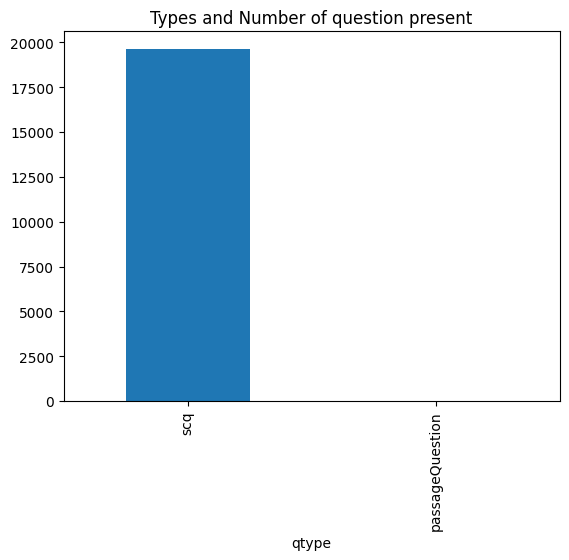

In [69]:
import matplotlib.pyplot as plt 
print(new_json_df.qtype.value_counts())
print("*"*50)
new_json_df.qtype.value_counts().plot(kind="bar",title="Types and Number of question present")

In [70]:
new_json_df.columns

Index(['_id', 'error', 'qtype', 'ocr_fields', 'has_dead_images', 'NCERTref',
       'ncert_source', 'Total_image_count', 'has_image', 'image_urls'],
      dtype='str')

In [71]:
new_json_df.ocr_fields[1]

{'question': {'field_path': 'scq.question',
  'ocr_text': '\\( F = 6 t \\) acts on a particle of mass 1 kg',
  'ocr_latex': 'F = 6 t \\text { acts on a particle of mass } 1 \\mathrm {~kg}',
  'avg_confidence': 0.0,
  'image_count': 1,
  'image_urls': ['https://acadza-check-new.s3.ap-south-1.amazonaws.com/GTfeMuauSimage.png'],
  'html': '<math xmlns="http://www.w3.org/1998/Math/MathML" display="inline"><mstyle displaystyle="true"><mrow><mi>F</mi><mo>&#x0003D;</mo><mn>6</mn><mi>t</mi></mrow></mstyle></math> acts on a particle of mass 1 kg',
  'latex_conversion_success': 1,
  'latex_conversion_fail': 0},
 'solution': {'field_path': 'scq.solution',
  'ocr_text': '\\( \\mathrm { F } = 6 \\mathrm { t } = \\frac { \\mathrm { mdv } } { \\mathrm { dt } } ; \\quad \\int _ { 0 } ^ { v } d v = \\int _ { 0 } ^ { 2 } 6 t d t \\)\n\\( V = 3 \\times 2 ^ { 2 } = 12 \\mathrm {~m} / \\mathrm { s } \\)\n\\( W = \\Delta K = \\frac { 1 } { 2 } m \\left( v ^ { 2 } - 0 ^ { 2 } \\right) = 72 J \\)',
  'ocr_lat

In [72]:
def extract_text_from_fields(row,field_names = ["question","solution"]):
    ocr_data = row.ocr_fields if isinstance(row.ocr_fields , dict) else {}
    texts = []
    for field in field_names:
        field_data = ocr_data.get(field, {})
        if isinstance(field_data , dict):
            text = field_data.get('ocr_text',"")
            if isinstance(text , str) and text.strip():
                texts.append(text)
    return " ".join(texts) if texts else ""

new_json_df["Combined_text"] = new_json_df.apply(lambda x : extract_text_from_fields(x), axis=1)
print(new_json_df[new_json_df['has_image']]['Combined_text'].iloc[0][:500] + "...")


\( A \cap \phi = \phi \)...


In [75]:
new_json_df.ocr_fields[1]

{'question': {'field_path': 'scq.question',
  'ocr_text': '\\( F = 6 t \\) acts on a particle of mass 1 kg',
  'ocr_latex': 'F = 6 t \\text { acts on a particle of mass } 1 \\mathrm {~kg}',
  'avg_confidence': 0.0,
  'image_count': 1,
  'image_urls': ['https://acadza-check-new.s3.ap-south-1.amazonaws.com/GTfeMuauSimage.png'],
  'html': '<math xmlns="http://www.w3.org/1998/Math/MathML" display="inline"><mstyle displaystyle="true"><mrow><mi>F</mi><mo>&#x0003D;</mo><mn>6</mn><mi>t</mi></mrow></mstyle></math> acts on a particle of mass 1 kg',
  'latex_conversion_success': 1,
  'latex_conversion_fail': 0},
 'solution': {'field_path': 'scq.solution',
  'ocr_text': '\\( \\mathrm { F } = 6 \\mathrm { t } = \\frac { \\mathrm { mdv } } { \\mathrm { dt } } ; \\quad \\int _ { 0 } ^ { v } d v = \\int _ { 0 } ^ { 2 } 6 t d t \\)\n\\( V = 3 \\times 2 ^ { 2 } = 12 \\mathrm {~m} / \\mathrm { s } \\)\n\\( W = \\Delta K = \\frac { 1 } { 2 } m \\left( v ^ { 2 } - 0 ^ { 2 } \\right) = 72 J \\)',
  'ocr_lat

In [77]:
new_json_df.Combined_text[1]

'\\( F = 6 t \\) acts on a particle of mass 1 kg \\( \\mathrm { F } = 6 \\mathrm { t } = \\frac { \\mathrm { mdv } } { \\mathrm { dt } } ; \\quad \\int _ { 0 } ^ { v } d v = \\int _ { 0 } ^ { 2 } 6 t d t \\)\n\\( V = 3 \\times 2 ^ { 2 } = 12 \\mathrm {~m} / \\mathrm { s } \\)\n\\( W = \\Delta K = \\frac { 1 } { 2 } m \\left( v ^ { 2 } - 0 ^ { 2 } \\right) = 72 J \\)'

In [ ]:
# ==============================================
# Feature Engineering
# ==============================================
# We'll build features that might indicate image presence:
# 1. Explicit image references (figure, diagram, graph, etc.)
# 2. Spatial language (as shown, above, below)
# 3. Visual element mentions (circuit, ray, plot, etc.)
# 4. Text patterns that suggest missing visual information
class ImageIndicatorFeatures:
    """Extract features that might indicate presence of images"""
    
    def __init__(self):
        # Keywords that strongly suggest images
        self.image_keywords = {
            'figure', 'fig.', 'diagram', 'graph', 'plot', 'circuit',
            'schematic', 'illustration', 'depicted', 'shown', 'picture',
            'sketch', 'drawing', 'chart', 'curve', 'ray diagram'
        }
        
        # Spatial references that might point to images
        self.spatial_refs = {
            'above', 'below', 'left', 'right', 'as shown',
            'in the figure', 'from the graph', 'in diagram'
        }
        
        # Subject-specific visual elements
        self.visual_elements = {
            # Physics
            'circuit', 'lens', 'mirror', 'ray', 'field lines',
            'waveform', 'oscilloscope', 'graph', 'vector',
            # Chemistry
            'structure', 'molecule', 'reaction mechanism',
            'apparatus', 'setup', 'titration', 'electrochemical cell',
            # Biology
            'cell', 'tissue', 'neuron', 'diagram', 'cross-section',
            'anatomy', 'microscope', 'slide'
        }
        
        # Patterns that might indicate missing image references
        self.patterns = [
            (r'as\s+shown\s+in\s+fig', 'fig_ref'),
            (r'in\s+the\s+(above|following|given)\s+(figure|diagram)', 'spatial_ref'),
            (r'from\s+the\s+graph', 'graph_ref'),
            (r'in\s+the\s+circuit', 'circuit_ref'),
            (r'ray\s+diagram', 'ray_diagram'),
            (r'according\s+to\s+the\s+figure', 'figure_ref'),
            (r'see\s+fig', 'see_fig')
        ]
    
    def extract_features(self, text):
        """Extract all image indicator features from text"""
        if not isinstance(text, str):
            text = ''
        
        text_lower = text.lower()
        features = {}
        
        # Keyword counts
        for kw in self.image_keywords:
            features[f'kw_{kw}'] = text_lower.count(kw)
        
        # Spatial reference counts
        for ref in self.spatial_refs:
            features[f'spatial_{ref.replace(" ", "_")}'] = text_lower.count(ref)
        
        # Visual elements
        for elem in self.visual_elements:
            features[f've_{elem.replace(" ", "_")}'] = text_lower.count(elem)
        
        # Pattern matching
        for pattern, name in self.patterns:
            features[f'pattern_{name}'] = len(re.findall(pattern, text_lower))
        
        # Aggregate features
        features['total_keyword_matches'] = sum(features.get(f'kw_{kw}', 0) for kw in self.image_keywords)
        features['total_spatial_refs'] = sum(features.get(f'spatial_{ref.replace(" ", "_")}', 0) for ref in self.spatial_refs)
        features['total_visual_elements'] = sum(features.get(f've_{elem.replace(" ", "_")}', 0) for elem in self.visual_elements)
        features['total_pattern_matches'] = sum(features.get(f'pattern_{name}', 0) for _, name in self.patterns)
        
        # Binary indicators
        features['has_image_keywords'] = features['total_keyword_matches'] > 0
        features['has_spatial_refs'] = features['total_spatial_refs'] > 0
        features['has_visual_elements'] = features['total_visual_elements'] > 0
        features['has_patterns'] = features['total_pattern_matches'] > 0
        
        return features

# Initialize feature extractor
feature_extractor = ImageIndicatorFeatures()

In [81]:
# Extract features for all questions
print("Extracting features from text...")
features_list = []

for idx, row in tqdm.tqdm(new_json_df.iterrows(), total=len(new_json_df)):
    features = feature_extractor.extract_features(row['Combined_text'])
    features['question_id'] = row['_id'].get('$oid', '') if isinstance(row['_id'], dict) else ''
    features['has_image_ground_truth'] = row['has_image']
    features_list.append(features)

features_df = pd.DataFrame(features_list)
print(f"\nExtracted {len(features_df.columns)} features")
features_df.head()

Extracting features from text...


  0%|          | 0/19633 [00:00<?, ?it/s]

100%|██████████| 19633/19633 [00:04<00:00, 3927.22it/s]



Extracted 65 features


,kw_schematic,kw_curve,kw_figure,kw_diagram,kw_chart,kw_illustration,kw_shown,kw_picture,kw_ray diagram,kw_graph,...,total_keyword_matches,total_spatial_refs,total_visual_elements,total_pattern_matches,has_image_keywords,has_spatial_refs,has_visual_elements,has_patterns,question_id,has_image_ground_truth
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,False,False,False,False,61024798bd61f315655274e0,True
1,0,0,0,0,0,0,0,0,0,0,...,0,2,0,0,False,True,False,False,63e78ccd8a90e86dacae5dbd,True
2,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,False,True,False,False,5f509f8fbd434d3145203a25,True
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,False,False,False,False,63e78ccd888a746db2a71464,True
4,0,0,0,0,0,0,0,0,0,0,...,0,3,0,0,False,True,False,False,5f509f8fbd434d3145203a26,True


In [85]:
new_json_df.head()

,_id,error,qtype,ocr_fields,has_dead_images,NCERTref,ncert_source,Total_image_count,has_image,image_urls,Combined_text
0,{'$oid': '61024798bd61f315655274e0'},1,scq,"{'solution': {'field_path': 'scq.solution', 'o...",False,NaN,NaN,1,True,[https://acadza-check-new.s3.ap-south-1.amazon...,\( A \cap \phi = \phi \)
1,{'$oid': '63e78ccd8a90e86dacae5dbd'},1,scq,"{'question': {'field_path': 'scq.question', 'o...",False,NaN,NaN,2,True,[https://acadza-check-new.s3.ap-south-1.amazon...,\( F = 6 t \) acts on a particle of mass 1 kg ...
2,{'$oid': '5f509f8fbd434d3145203a25'},1,scq,"{'solution': {'field_path': 'scq.solution', 'o...",False,NaN,NaN,2,True,[https://acadza-check.s3.amazonaws.com/91vnwyK...,\( \sin ^ { 2 } \theta = \frac { 1 } { 4 } = \...
3,{'$oid': '63e78ccd888a746db2a71464'},1,scq,"{'solution': {'field_path': 'scq.solution', 'o...",False,NaN,NaN,1,True,[https://acadza-check-new.s3.ap-south-1.amazon...,\( E _ { \text {outside } } = \frac { Q } { 4 ...
4,{'$oid': '5f509f8fbd434d3145203a26'},1,scq,"{'solution': {'field_path': 'scq.solution', 'o...",False,NaN,NaN,1,True,[https://acadza-check.s3.amazonaws.com/Q2t_xC5gu],\( \cos ^ { 2 } \theta = \frac { 3 } { 4 } = \...


In [86]:
# ==============================================
# EXPLORATORY ANALYSIS: Feature Importance
# ==============================================

# Compare feature distributions between questions with and without images
image_questions = features_df[features_df['has_image_ground_truth']]
no_image_questions = features_df[~features_df['has_image_ground_truth']]

print("Feature presence in questions WITH images:")
print(f"Has image keywords: {image_questions['has_image_keywords'].mean():.2%}")
print(f"Has spatial references: {image_questions['has_spatial_refs'].mean():.2%}")
print(f"Has visual elements: {image_questions['has_visual_elements'].mean():.2%}")
print(f"Has patterns: {image_questions['has_patterns'].mean():.2%}")

print("\nFeature presence in questions WITHOUT images:")
print(f"Has image keywords: {no_image_questions['has_image_keywords'].mean():.2%}")
print(f"Has spatial references: {no_image_questions['has_spatial_refs'].mean():.2%}")
print(f"Has visual elements: {no_image_questions['has_visual_elements'].mean():.2%}")
print(f"Has patterns: {no_image_questions['has_patterns'].mean():.2%}")

Feature presence in questions WITH images:
Has image keywords: 3.89%
Has spatial references: 65.40%
Has visual elements: 28.58%
Has patterns: 0.69%

Feature presence in questions WITHOUT images:
Has image keywords: 0.00%
Has spatial references: 0.00%
Has visual elements: 0.00%
Has patterns: 0.00%


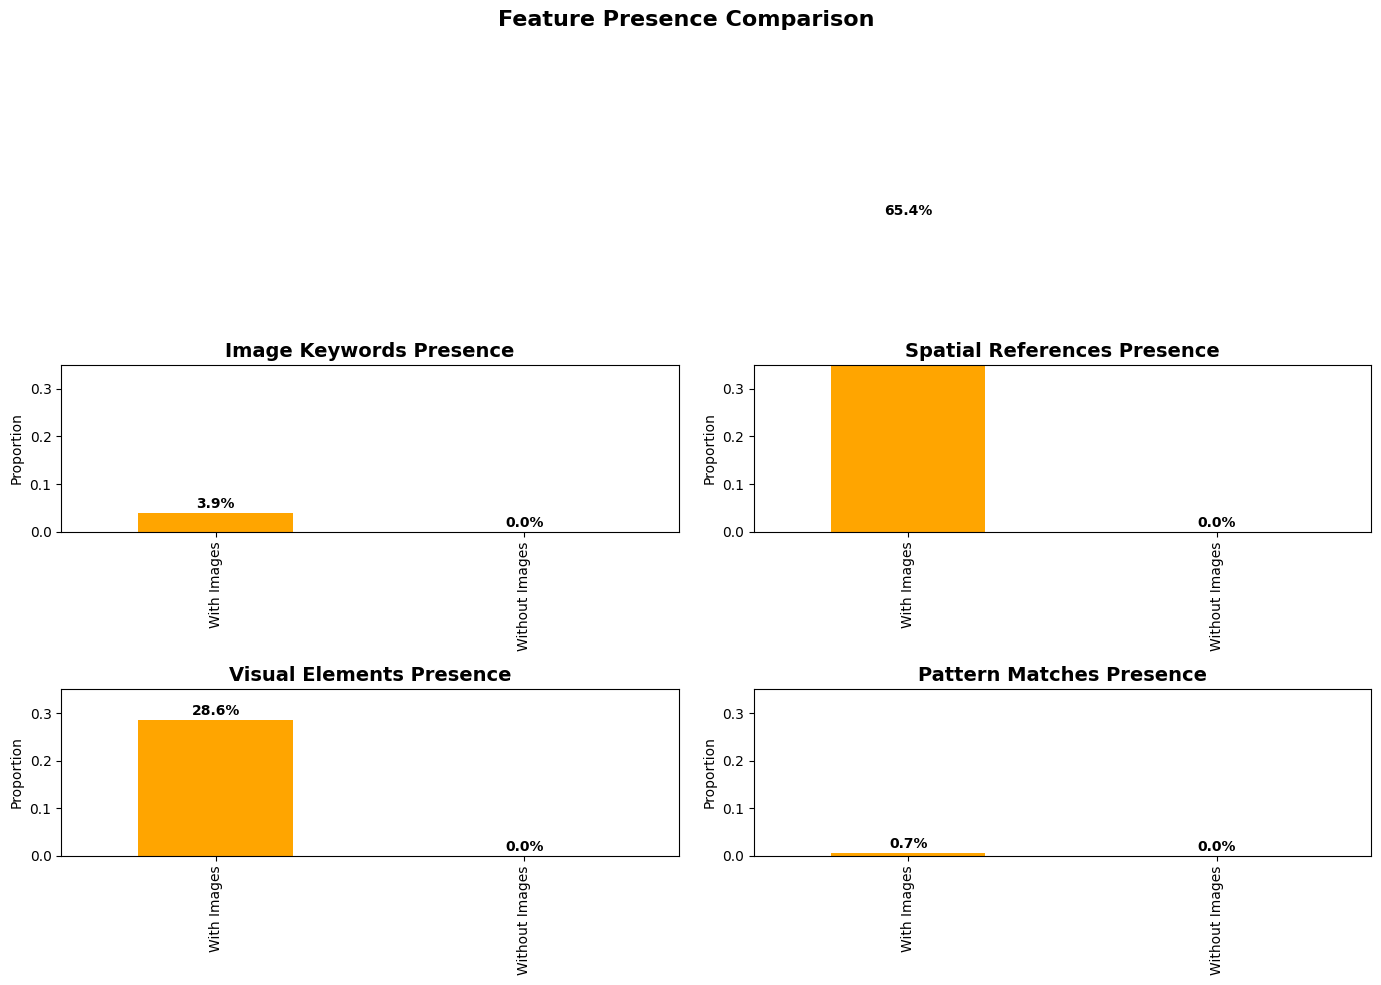

In [87]:
# Visualize the differences
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

features_to_plot = ['has_image_keywords', 'has_spatial_refs', 'has_visual_elements', 'has_patterns']
titles = ['Image Keywords Presence', 'Spatial References Presence', 
          'Visual Elements Presence', 'Pattern Matches Presence']

for idx, (feat, title) in enumerate(zip(features_to_plot, titles)):
    row, col = idx // 2, idx % 2
    
    data = pd.DataFrame({
        'With Images': [image_questions[feat].mean()],
        'Without Images': [no_image_questions[feat].mean()]
    }).T
    
    data[0].plot(kind='bar', ax=axes[row, col], color=['orange', 'blue'])
    axes[row, col].set_title(title, fontsize=14, fontweight='bold')
    axes[row, col].set_ylabel('Proportion')
    axes[row, col].set_ylim(0, 0.35)
    
    # Add value labels
    for i, v in enumerate(data[0]):
        axes[row, col].text(i, v + 0.01, f'{v:.1%}', ha='center', fontweight='bold')

plt.suptitle('Feature Presence Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [90]:
# ==============================================
# CREATIVE APPROACH 1: N-gram Analysis
# ==============================================
# Let's find distinctive n-grams that characterize image-containing questions

# Prepare text data
texts_with_images = new_json_df[new_json_df['has_image']]['Combined_text'].fillna('').tolist()
texts_without_images = new_json_df[~new_json_df['has_image']]['Combined_text'].fillna('').tolist()

# Sample to balance for analysis (since we have many more without images)
np.random.seed(42)
sample_size = min(len(texts_with_images) * 5, len(texts_without_images))
texts_without_images_sample = np.random.choice(texts_without_images, size=sample_size, replace=False)

# Combine for analysis
all_texts = texts_with_images + texts_without_images_sample.tolist()
labels = [1] * len(texts_with_images) + [0] * len(texts_without_images_sample)

# Extract n-grams (1-3 grams)
vectorizer = CountVectorizer(ngram_range=(1, 3), max_features=1000, stop_words='english')
X = vectorizer.fit_transform(all_texts)
feature_names = vectorizer.get_feature_names_out()

# Chi-square test for feature importance
chi2_scores, p_values = chi2(X, labels)

# Create dataframe of important features
important_features = pd.DataFrame({
    'ngram': feature_names,
    'chi2_score': chi2_scores,
    'p_value': p_values
}).sort_values('chi2_score', ascending=False)

print("Top 20 n-grams associated with image presence:")
important_features.head(20)

Top 20 n-grams associated with image presence:


,ngram,chi2_score,p_value
536,mathrm,3.964700,0.046464
274,frac,3.520782,0.060604
769,right,1.514008,0.218529
453,left,1.511817,0.218862
581,mathrm mathrm,1.065862,0.301882
932,times,0.862215,0.353120
811,rightarrow,0.857936,0.354317
109,array,0.767319,0.381048
3,10,0.583282,0.445029
870,sqrt,0.581958,0.445546
